# Прогнозирование конечных свойств композиционных материалов

Этот notebook воспроизводит исследование через модули `composites` и читает
опубликованные отчёты проекта. По умолчанию дорогостоящий подбор моделей не
повторяется. Отложенная test-выборка представлена только в артефактах
окончательной оценки, созданных после фиксации решений по train/CV.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from composites.data import load_and_merge
from composites.evaluation import run_evaluation
from composites.inference import load_direct_predictor
from composites.training import run_training

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Запустите notebook из корня проекта или каталога notebooks")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
RETRAIN_ALL_MODELS = False
print(f"Project: {PROJECT_ROOT}")

Project: /workspace


## Режим воспроизведения

`RETRAIN_ALL_MODELS=False` читает уже опубликованные результаты и подходит
для просмотра. Значение `True` последовательно повторяет train-only
GridSearch, 10-fold CV и refit через `composites.training.run_training`,
затем один раз пересоздаёт evaluation, manifest и рисунки через
`composites.evaluation.run_evaluation`. Test не используется для подбора,
потому что выбор сначала фиксируется в `model_selection.json`.

In [2]:
if RETRAIN_ALL_MODELS:
    training_result = run_training(
        PROJECT_ROOT,
        data_dir=DATA_DIR,
        split_path=PROJECT_ROOT / "data" / "splits.json",
        models_dir=MODELS_DIR,
        reports_dir=REPORTS_DIR / "modeling",
    )
    evaluation_result = run_evaluation(
        PROJECT_ROOT,
        data_dir=DATA_DIR,
        split_path=PROJECT_ROOT / "data" / "splits.json",
        selection_path=REPORTS_DIR / "modeling" / "model_selection.json",
        models_dir=MODELS_DIR,
        reports_dir=REPORTS_DIR / "evaluation",
        figures_dir=FIGURES_DIR / "evaluation",
        results_doc=PROJECT_ROOT / "docs" / "results.md",
    )
    display(training_result["metadata"])
    display({"evaluation_elapsed_seconds": evaluation_result["elapsed_seconds"]})
else:
    print("Повторное обучение отключено; используются опубликованные результаты.")

Повторное обучение отключено; используются опубликованные результаты.


## Источники, INNER JOIN и аудит

Два XLSX объединяются по проверенному `source_index` отношением one-to-one.
В notebook вызывается проектный загрузчик, а контрольные сведения берутся
из опубликованного audit JSON, без копирования логики загрузки.

In [3]:
merged, unmatched = load_and_merge(DATA_DIR)
audit = json.loads((REPORTS_DIR / "data_audit.json").read_text(encoding="utf-8"))
source_table = pd.DataFrame(
    [
        {"source": name, "rows": item["rows"], "sha256": item["sha256"]}
        for name, item in audit["sources"].items()
    ]
)
display(source_table)
display({"inner_join_shape": merged.shape, "unmatched": unmatched})

,source,rows,sha256
0,X_bp.xlsx,1023,14b6a82bdc7511c15a8e58397cf42855e9ffa51baa289b...
1,X_nup.xlsx,1040,1c7aa1be64596020f5621ca72f0d0de43d2dc689ca48ff...


{'inner_join_shape': (1023, 14),
 'unmatched': {'only_in_x_bp': [],
  'only_in_x_nup': [1023,
   1024,
   1025,
   1026,
   1027,
   1028,
   1029,
   1030,
   1031,
   1032,
   1033,
   1034,
   1035,
   1036,
   1037,
   1038,
   1039]}}

## Разбиение и защита от утечки

Единственное разбиение 70/30 зафиксировано заранее. Десять KFold-разбиений
находятся только внутри train. EDA, scaler, IQR-границы и GridSearch не
используют 307 отложенных строк до окончательной оценки.

In [4]:
split = json.loads((PROJECT_ROOT / "data" / "splits.json").read_text("utf-8"))
split_overview = {
    "train_rows": len(split["train_indices"]),
    "test_rows": len(split["test_indices"]),
    "cv_folds": len(split["cv_folds"]),
    "random_state": split["protocol"]["random_state"],
}
display(split_overview)

{'train_rows': 716, 'test_rows': 307, 'cv_folds': 10, 'random_state': 42}

## EDA: распределения train

Гистограммы показывают форму распределений и хвосты на 716 train-строках.
Они не являются основанием автоматически удалять редкие наблюдения.

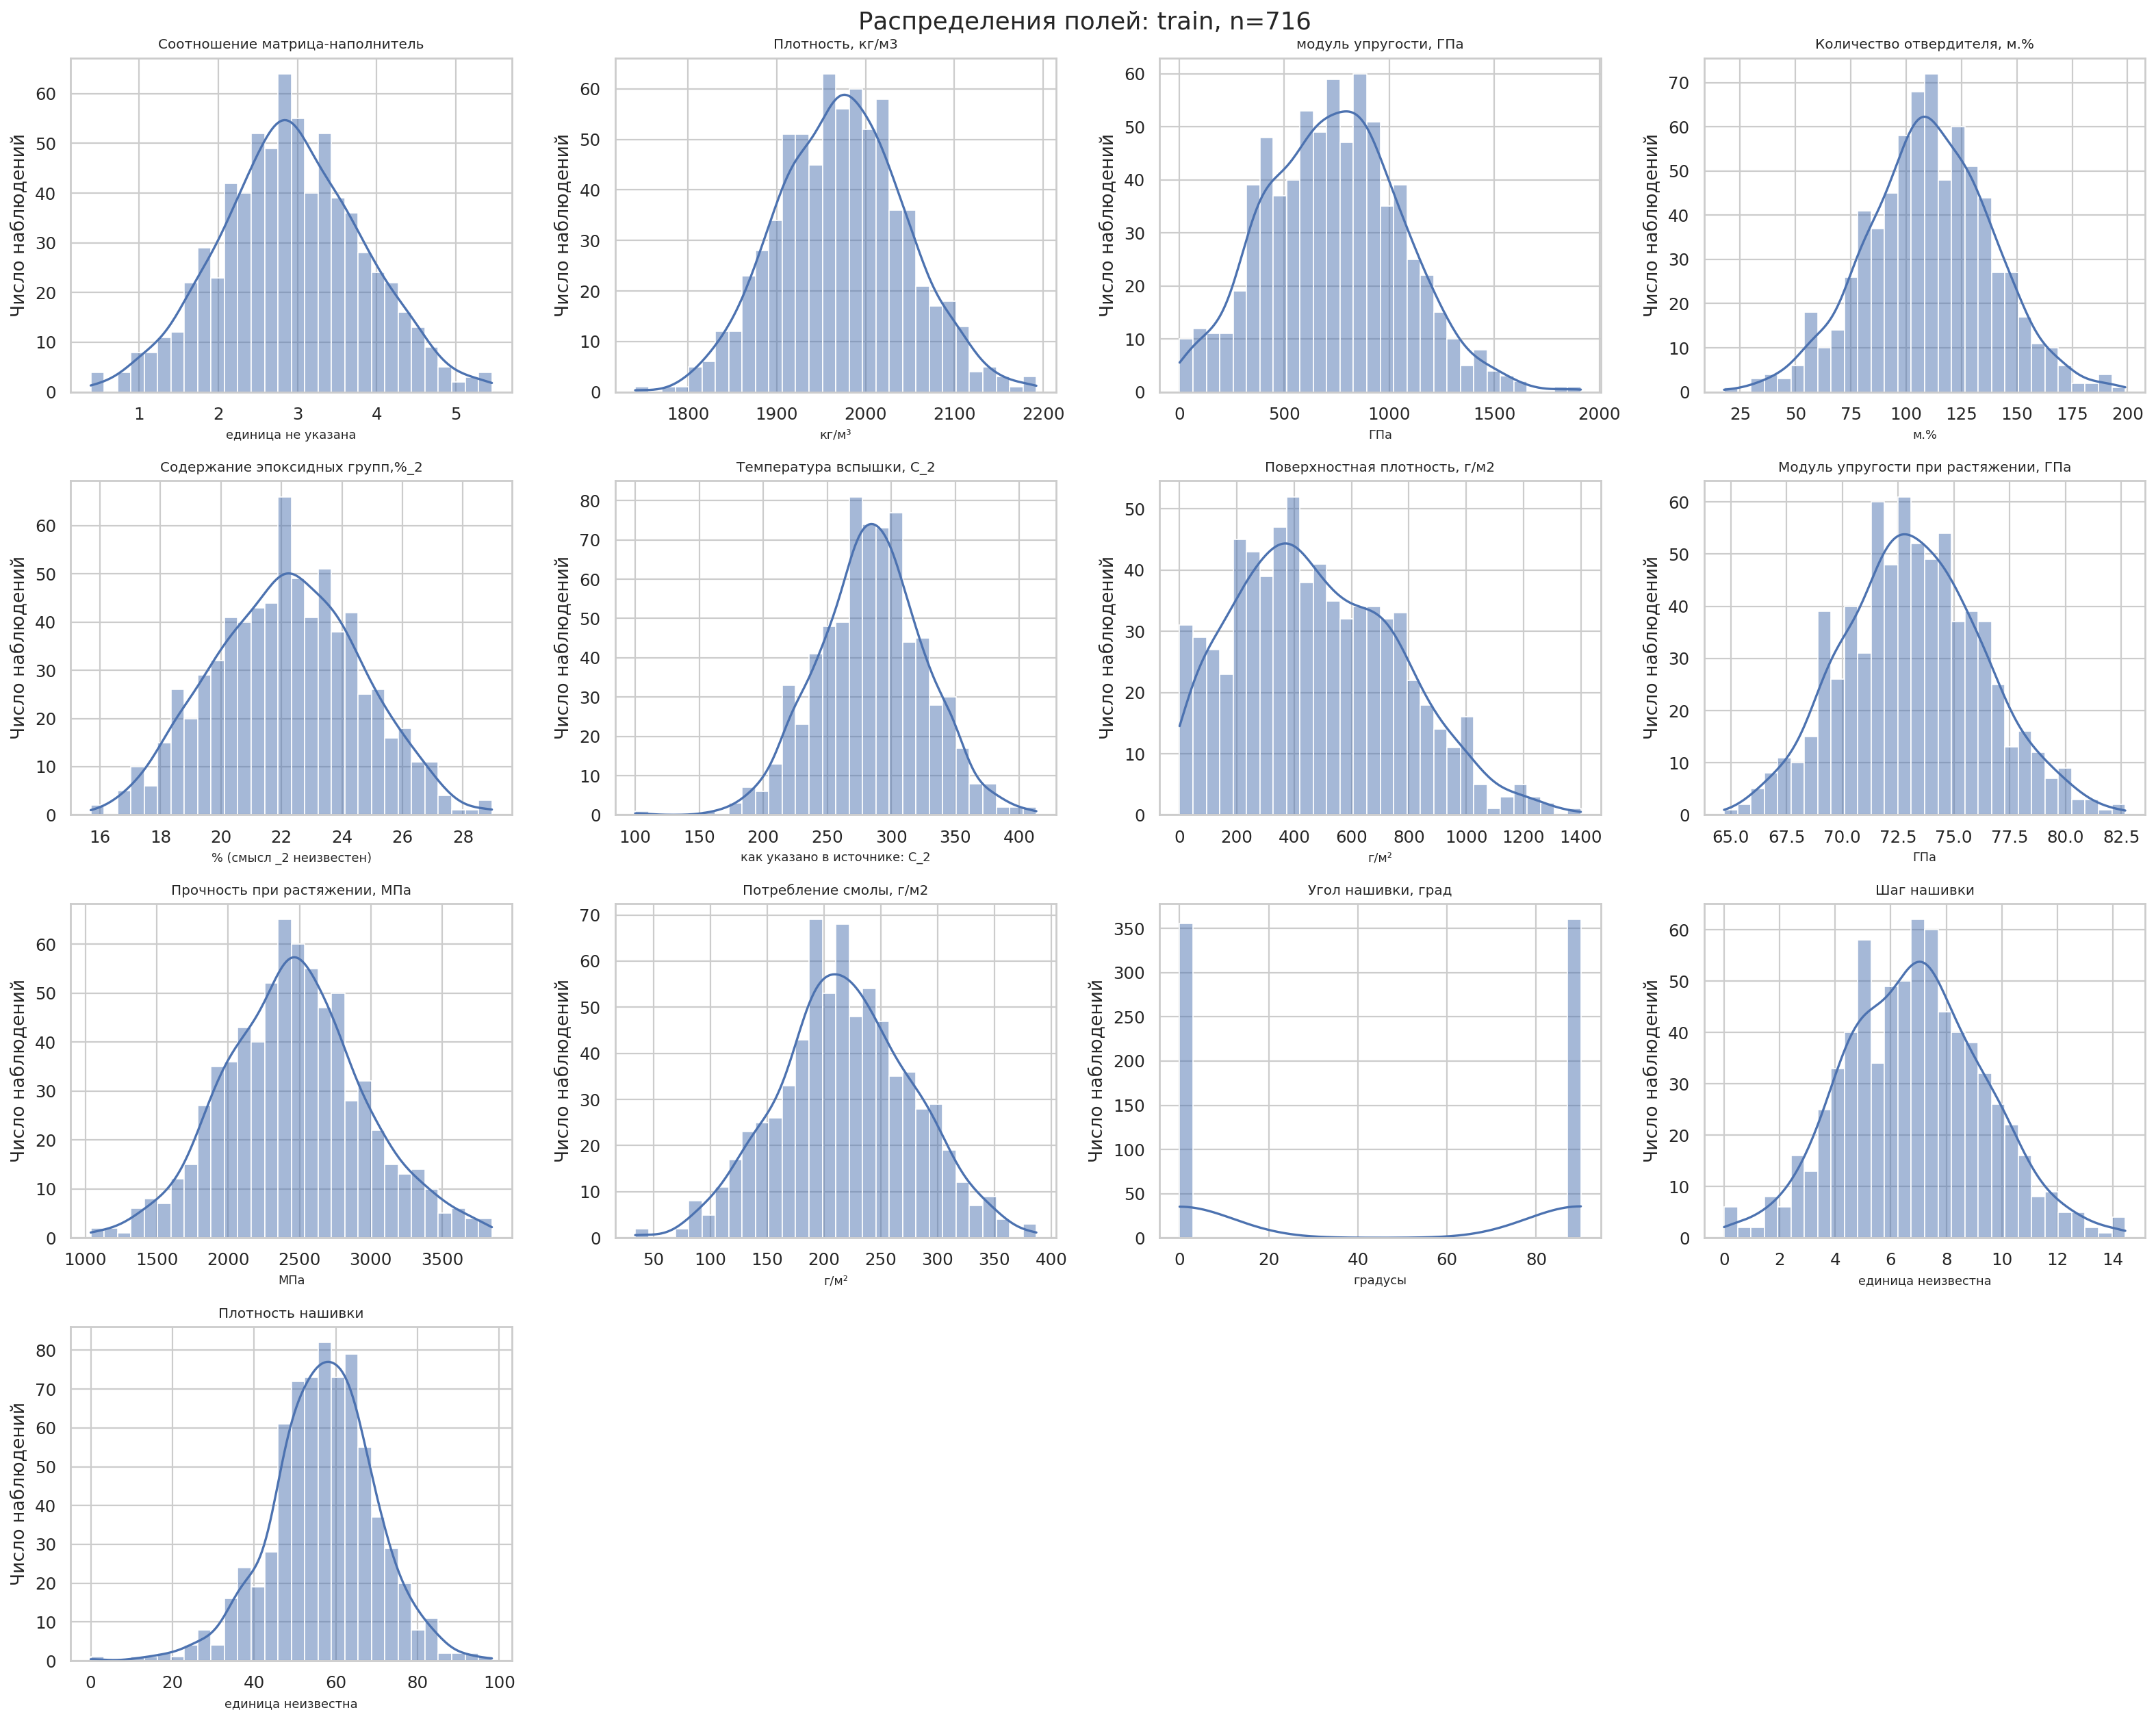

In [5]:
display(Image(filename=str(FIGURES_DIR / 'eda' / 'histograms_train.png')))

### Кандидаты по правилу 1,5 IQR

Точки за усами boxplot — статистические кандидаты, а не доказанные ошибки.
IQR-фильтрация сравнена внутри кросс-валидации: границы оцениваются только на обучающей части фолда, а проверочные и отложенные строки не удаляются.

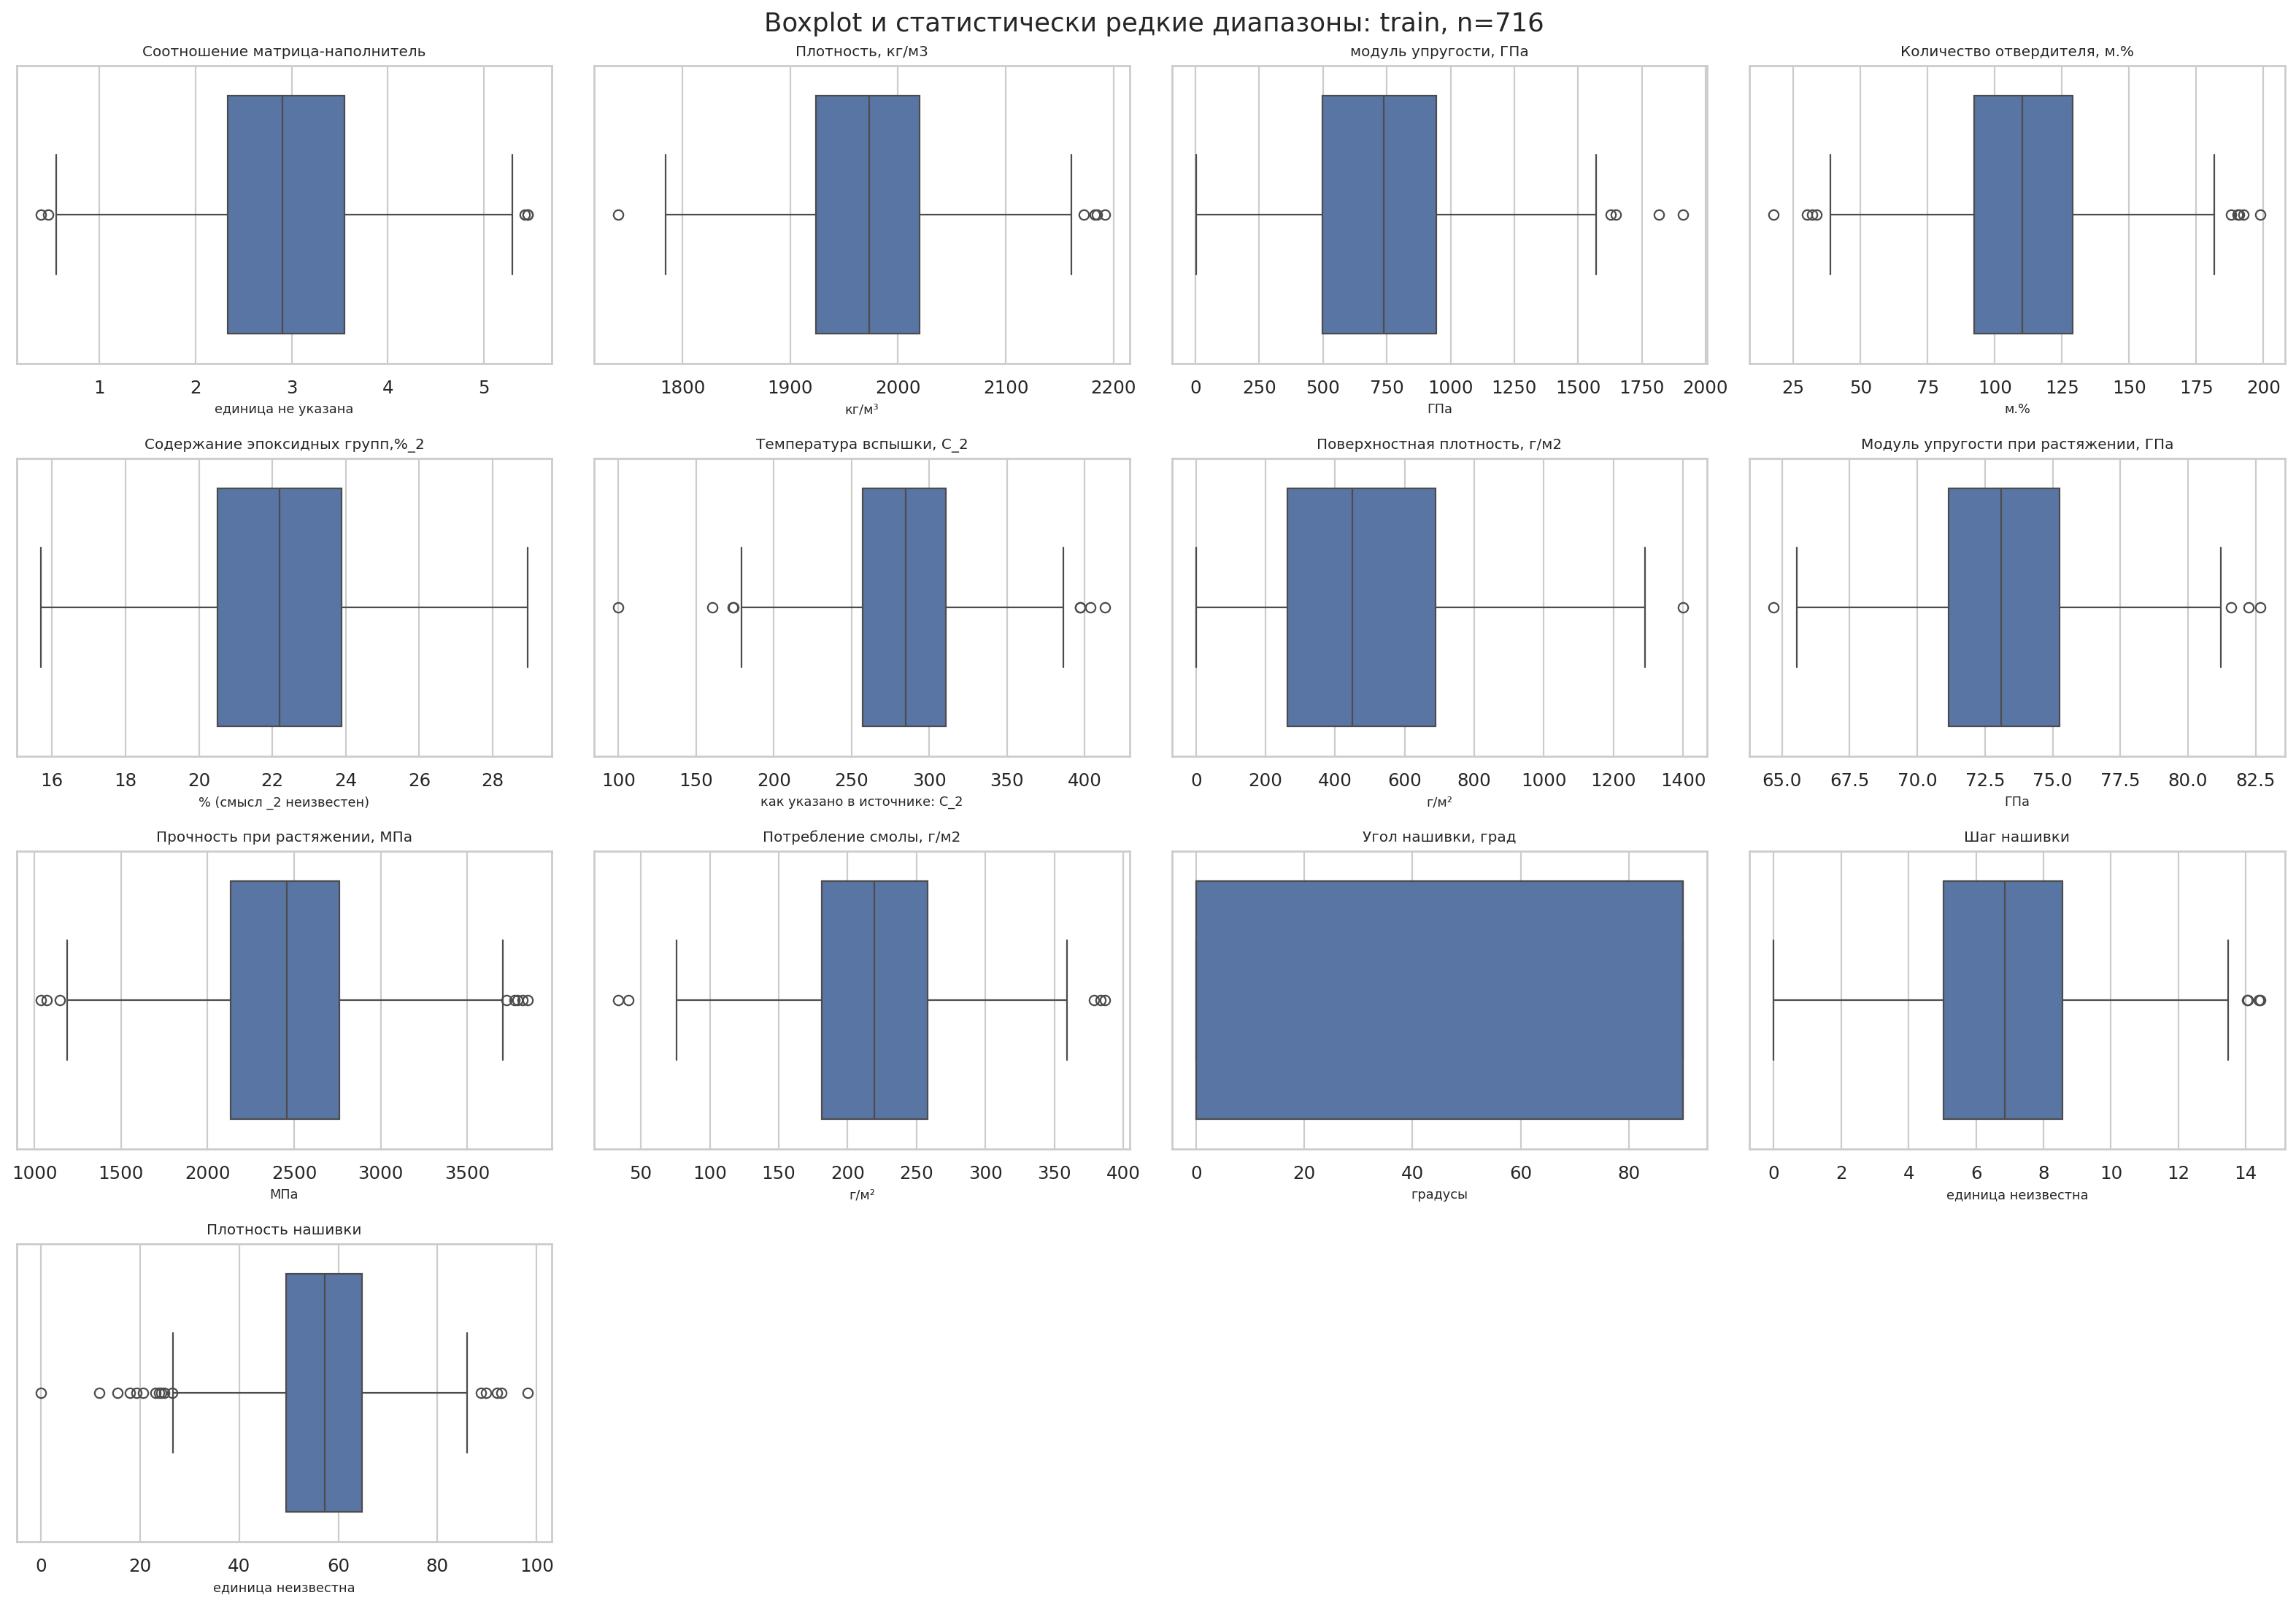

In [6]:
display(Image(filename=str(FIGURES_DIR / 'eda' / 'boxplots_train.png')))

### Корреляции

Pearson и Spearman описывают линейные и монотонные связи на train.
Слабые коэффициенты и неизвестное происхождение данных не допускают
причинной трактовки.

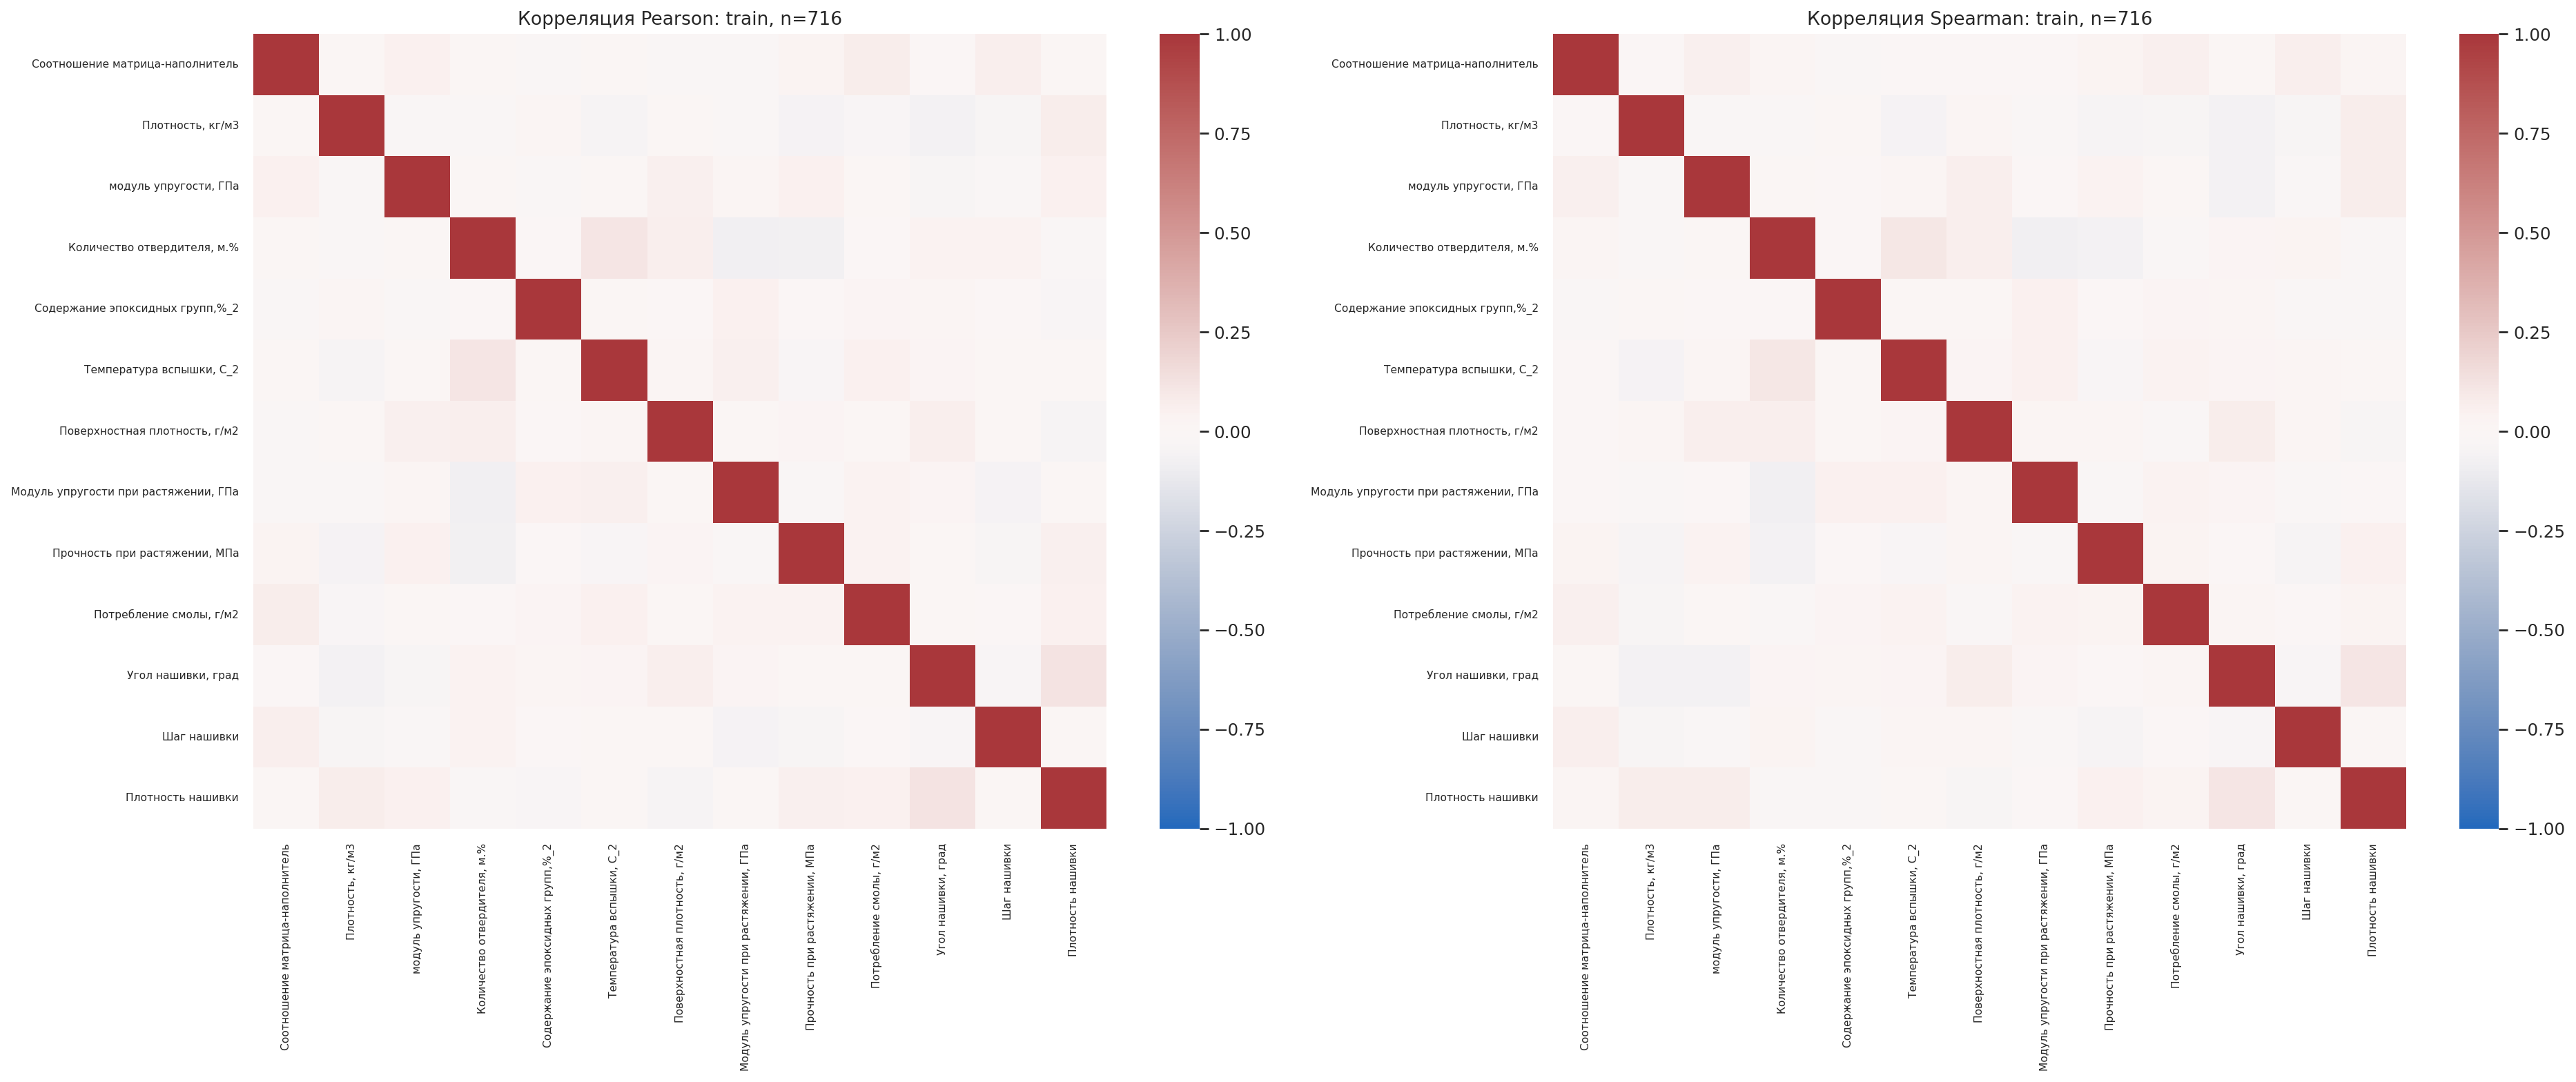

In [7]:
display(Image(filename=str(FIGURES_DIR / 'eda' / 'correlations_train.png')))

### Иллюстрация масштабирования

Рисунок показывает MinMax-преобразование только как иллюстрацию. В моделях
нужные scaler обучаются заново внутри каждого CV-фолда и входят в pipeline.

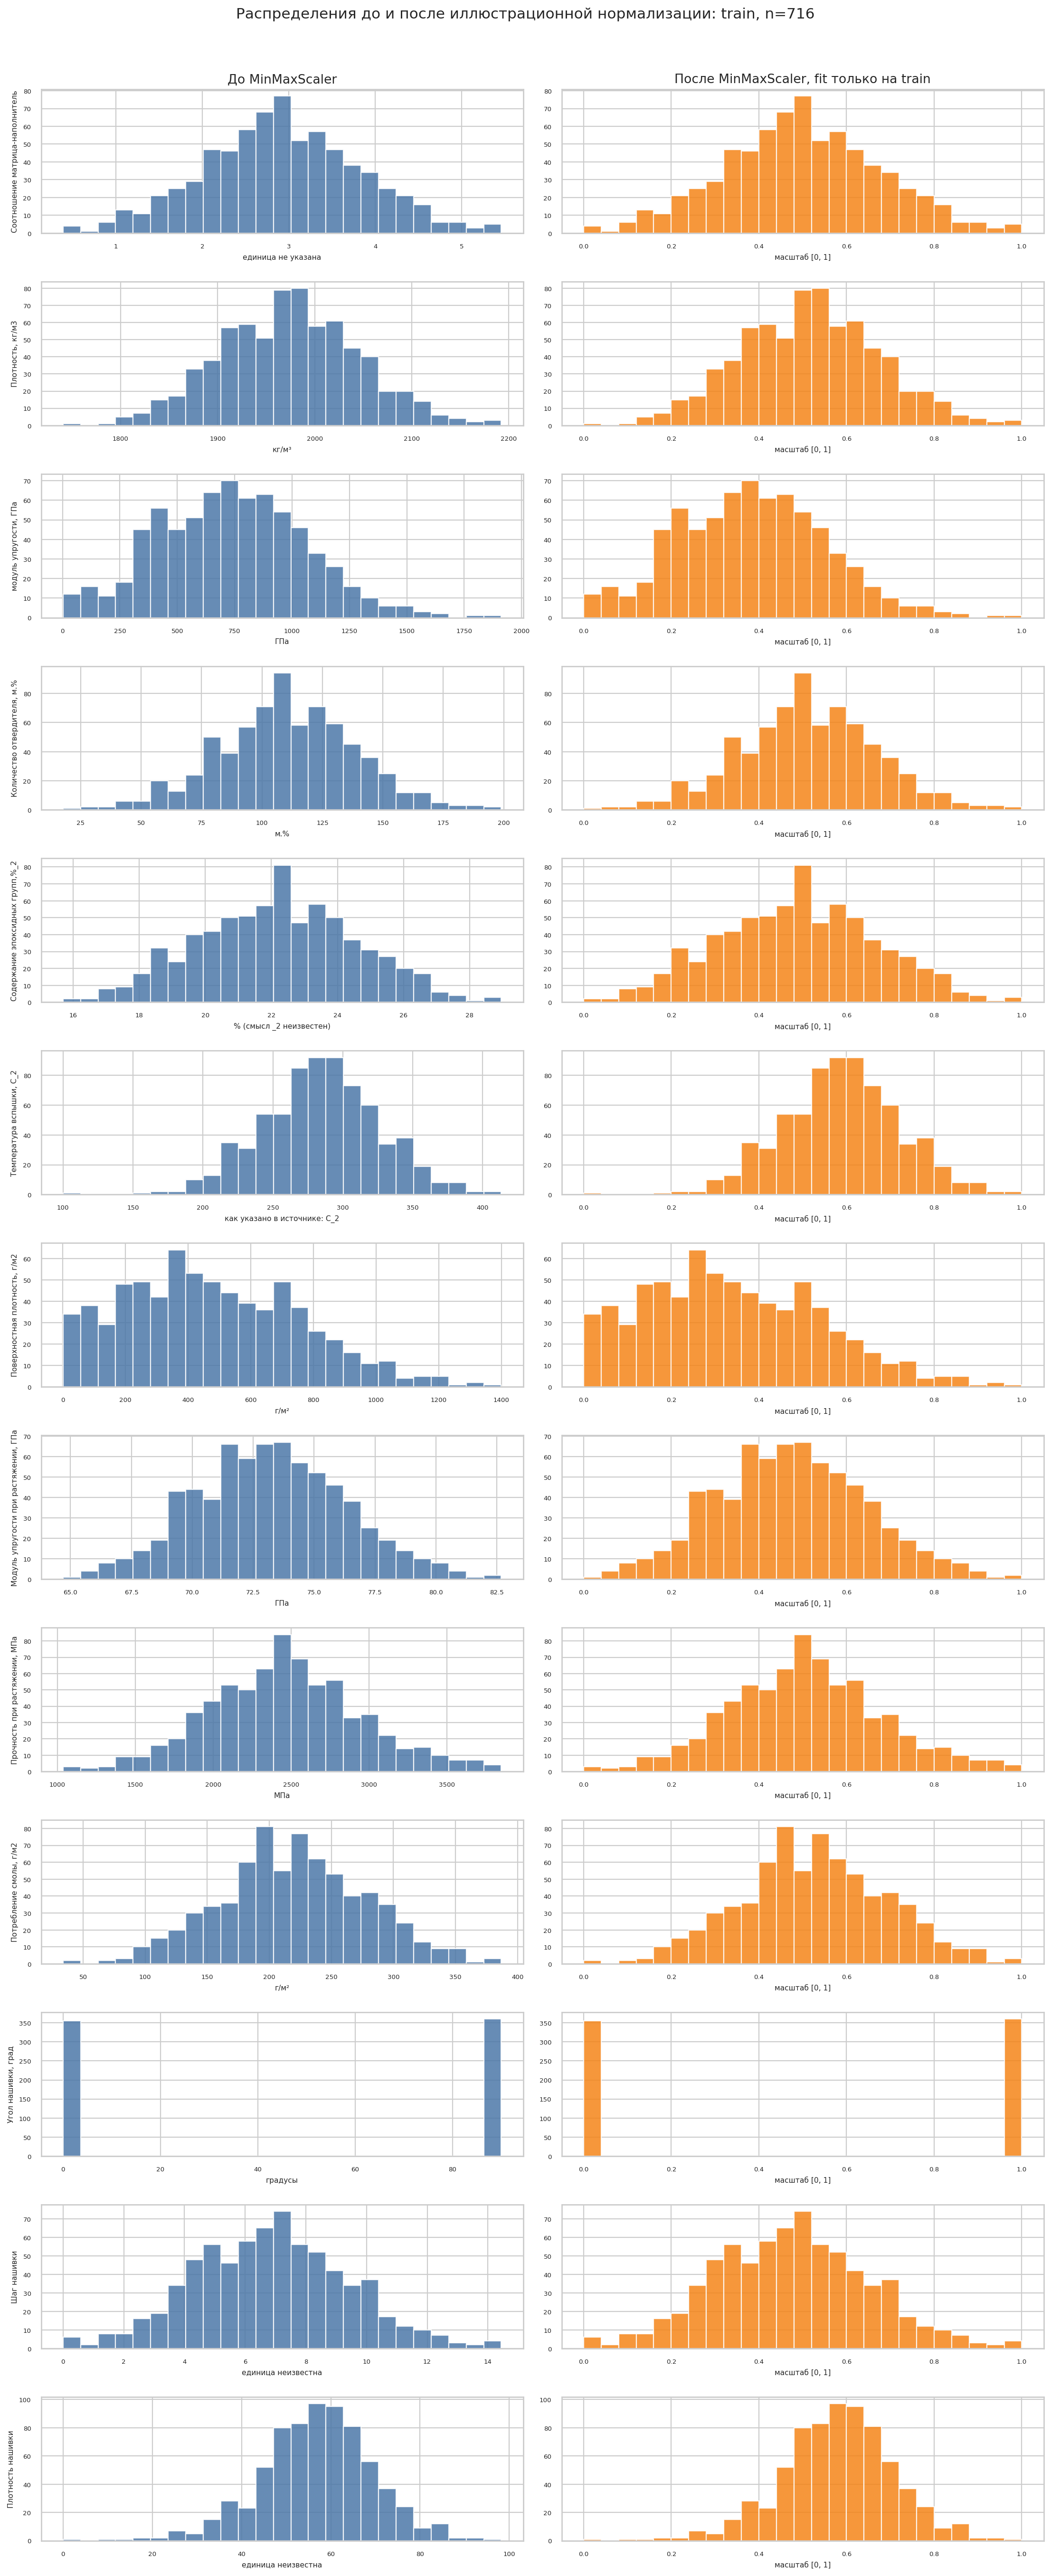

In [8]:
display(Image(filename=str(FIGURES_DIR / 'eda' / 'normalization_before_after_train.png')))

### Полный комплект EDA

Выше встроены четыре репрезентативных сводных рисунка. Все шесть блоков
попарных диаграмм остаются отдельными файлами в `figures/eda`, чтобы notebook
не дублировал крупные PNG. Следующая таблица даёт их относительные пути.

In [9]:
pairwise_figures = sorted((FIGURES_DIR / "eda").glob("scatter_block_*_train.png"))
display(pd.DataFrame({"pairwise_figure": [str(path.relative_to(PROJECT_ROOT)) for path in pairwise_figures]}))

,pairwise_figure
0,figures/eda/scatter_block_1_1_train.png
1,figures/eda/scatter_block_1_2_train.png
2,figures/eda/scatter_block_1_3_train.png
3,figures/eda/scatter_block_2_2_train.png
4,figures/eda/scatter_block_2_3_train.png
5,figures/eda/scatter_block_3_3_train.png


In [10]:
eda_summary = pd.read_csv(REPORTS_DIR / "eda" / "summary.csv")
outliers = pd.read_csv(REPORTS_DIR / "eda" / "outliers.csv")
display(eda_summary)
display(outliers.sort_values("candidate_count", ascending=False).head())

,variable,count,mean,median,min,max,std,null_count,unique_count
0,Соотношение матрица-наполнитель,716,2.921322,2.900123,0.389403,5.455566,0.907610,0,711
1,"Плотность, кг/м3",716,1973.803262,1973.063180,1740.657496,2192.297637,71.618112,0,709
2,"модуль упругости, ГПа",716,735.550574,738.736842,2.436909,1911.536477,323.545926,0,715
3,"Количество отвердителя, м.%",716,110.466992,110.282718,17.740275,198.953207,28.356947,0,702
4,"Содержание эпоксидных групп,%_2",716,22.184799,22.200872,15.695894,28.955094,2.391527,0,701
5,"Температура вспышки, С_2",716,284.386234,284.615385,100.000000,413.273418,41.563648,0,701
6,"Поверхностная плотность, г/м2",716,479.424636,449.051543,0.603740,1399.542362,280.728742,0,702
7,"Модуль упругости при растяжении, ГПа",716,73.207346,73.108522,64.696400,82.682051,3.096838,0,702
8,"Прочность при растяжении, МПа",716,2464.533846,2455.555556,1036.856605,3848.436732,490.839665,0,702
9,"Потребление смолы, г/м2",716,219.342512,219.478456,33.803026,386.903431,58.851046,0,701


,variable,q1,q3,iqr,lower_bound,upper_bound,candidate_count,candidate_share
11,Плотность нашивки,49.504402,64.798211,15.293809,26.563689,87.738924,16,0.022346
3,"Количество отвердителя, м.%",92.419921,129.045854,36.625933,37.481020,183.984754,9,0.012570
5,"Температура вспышки, С_2",257.160185,310.781116,53.620931,176.728788,391.212513,8,0.011173
8,"Прочность при растяжении, МПа",2132.791054,2762.637197,629.846144,1188.021839,3707.406413,8,0.011173
0,Соотношение матрица-наполнитель,2.331625,3.548143,1.216519,0.506847,5.372921,5,0.006983


## Классические модели и GridSearch

Для двух прямых целей сравниваются Dummy baseline, Ridge, Random Forest,
Gradient Boosting и SVR. Основной критерий — средний validation RMSE в
исходной единице цели. Преобразования X/y и IQR-вариант находятся внутри
pipeline, поэтому каждый фолд обучает их заново.

In [11]:
cv_summary = pd.read_csv(REPORTS_DIR / "modeling" / "cv_summary.csv")
display(cv_summary.sort_values(["task", "cv_rmse_mean"]))
display(cv_summary.loc[cv_summary["selected"]])

,task,family,variant,candidate_id,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,train_cv_rmse_mean,selected
0,direct_tensile_modulus,baseline,raw,direct_tensile_modulus:baseline:raw:44136fa355,3.087310,0.257094,2.482899,-0.015061,3.094354,True
1,direct_tensile_modulus,ridge,iqr_filtered,direct_tensile_modulus:ridge:iqr_filtered:aa6e...,3.111325,0.255041,2.507161,-0.031767,3.062481,False
3,direct_tensile_modulus,gradient_boosting,iqr_filtered,direct_tensile_modulus:gradient_boosting:iqr_f...,3.120246,0.276788,2.492943,-0.036299,2.847162,False
2,direct_tensile_modulus,random_forest,iqr_filtered,direct_tensile_modulus:random_forest:iqr_filte...,3.129759,0.285499,2.499677,-0.042510,1.829668,False
4,direct_tensile_modulus,svr,raw,direct_tensile_modulus:svr:raw:cc7290443d,3.137009,0.247435,2.513317,-0.049762,2.804692,False
8,direct_tensile_strength,gradient_boosting,raw,direct_tensile_strength:gradient_boosting:raw:...,490.208727,23.852396,387.224700,-0.010280,445.491297,True
5,direct_tensile_strength,baseline,raw,direct_tensile_strength:baseline:raw:44136fa355,490.499769,24.618096,384.750224,-0.010938,490.462901,False
6,direct_tensile_strength,ridge,raw,direct_tensile_strength:ridge:raw:d760ee1674,491.660984,22.422976,387.164964,-0.016228,484.753772,False
7,direct_tensile_strength,random_forest,raw,direct_tensile_strength:random_forest:raw:eb60...,494.074844,24.914144,391.220534,-0.026307,289.425314,False
9,direct_tensile_strength,svr,raw,direct_tensile_strength:svr:raw:cc7290443d,494.236343,22.094044,389.938058,-0.027434,445.943251,False


,task,family,variant,candidate_id,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,train_cv_rmse_mean,selected
0,direct_tensile_modulus,baseline,raw,direct_tensile_modulus:baseline:raw:44136fa355,3.087310,0.257094,2.482899,-0.015061,3.094354,True
8,direct_tensile_strength,gradient_boosting,raw,direct_tensile_strength:gradient_boosting:raw:...,490.208727,23.852396,387.224700,-0.010280,445.491297,True
11,matrix_filler_ratio,mlp,raw,matrix_filler_ratio:mlp:raw:a957c09ff4,0.935319,0.057695,0.750579,-0.072470,0.869784,True


### CV RMSE по семействам

Высота столбца — средняя ошибка validation-фолдов. Сравнивать абсолютные
значения между целями с разными единицами нельзя; константная модель остаётся точкой сравнения и выбирается, если получает минимальную среднюю CV RMSE.

In [12]:
axes = cv_summary.pivot(index="family", columns="task", values="cv_rmse_mean").plot(
    kind="bar", subplots=True, layout=(-1, 1), figsize=(10, 9), legend=False
)
plt.tight_layout()
plt.show()

## MLP для отношения матрица–наполнитель

MLP выполняет обратную регрессию отношения по 12 полям полного профиля, включая заданные механические свойства. Это математическая трактовка рекомендации, но не оптимизация состава и не причинная модель. Проверка random_state 42–44 отражает совместное влияние инициализации весов, внутреннего разбиения и мини-батчей; три значения не доказывают общую устойчивость.

In [13]:
nn_stability = pd.read_csv(REPORTS_DIR / "modeling" / "nn_stability.csv")
nn_history = pd.read_csv(REPORTS_DIR / "modeling" / "nn_history.csv")
display(nn_stability.groupby("seed")["validation_rmse"].agg(["mean", "std"]))

,mean,std
seed,,
42,0.935319,0.060816
43,0.939617,0.067758
44,0.947864,0.077173


### Устойчивость MLP по seed

Точки — RMSE отдельных validation-фолдов. Разброс показывает чувствительность
обучения; он не превращается в доверительный интервал единичного прогноза.

In [14]:
nn_stability.boxplot(column="validation_rmse", by="seed", figsize=(8, 4))
plt.suptitle("")
plt.title("MLP: validation RMSE по seed")
plt.ylabel("RMSE отношения")
plt.show()

## Единственное открытие test и окончательная оценка

Следующая клетка проверяет наличие опубликованных метрик, построчных
прогнозов, permutation importance, evaluation-рисунков и manifest
приложения. Графики связаны с опубликованными числовыми отчётами и сохранёнными моделями.

In [15]:
s09_required = [
    REPORTS_DIR / "evaluation" / "metrics.csv",
    REPORTS_DIR / "evaluation" / "predictions.csv",
    REPORTS_DIR / "evaluation" / "permutation_importance.csv",
    MODELS_DIR / "model_manifest.json",
]
missing = [str(path.relative_to(PROJECT_ROOT)) for path in s09_required if not path.is_file()]
evaluation_figures = sorted((FIGURES_DIR / "evaluation").glob("*.png"))
if not evaluation_figures:
    missing.append("figures/evaluation/*.png")
if missing:
    raise RuntimeError(f"Отсутствуют результаты итоговой оценки: {missing}. Запустите scripts/evaluate_models.py.")

metrics = pd.read_csv(s09_required[0])
predictions = pd.read_csv(s09_required[1])
importance = pd.read_csv(s09_required[2])
display(metrics.sort_values(["task", "partition", "rmse"]))

,task,family,partition,n,rmse,mae,r2,selected,artifact
1,direct_tensile_modulus,baseline,test,307,3.177672,2.556417,-0.016426,True,models/direct_tensile_modulus_baseline.joblib
3,direct_tensile_modulus,ridge,test,307,3.189873,2.566603,-0.024246,False,models/direct_tensile_modulus_rank1.joblib
5,direct_tensile_modulus,gradient_boosting,test,307,3.221146,2.586649,-0.044427,False,models/direct_tensile_modulus_rank2.joblib
9,direct_tensile_modulus,svr,test,307,3.263156,2.622800,-0.071848,False,models/direct_tensile_modulus_rank4.joblib
7,direct_tensile_modulus,random_forest,test,307,3.311191,2.642923,-0.103636,False,models/direct_tensile_modulus_rank3.joblib
6,direct_tensile_modulus,random_forest,train,716,1.816880,1.334426,0.655315,False,models/direct_tensile_modulus_rank3.joblib
8,direct_tensile_modulus,svr,train,716,2.812584,2.137385,0.173999,False,models/direct_tensile_modulus_rank4.joblib
4,direct_tensile_modulus,gradient_boosting,train,716,2.867140,2.292795,0.141643,False,models/direct_tensile_modulus_rank2.joblib
2,direct_tensile_modulus,ridge,train,716,3.065807,2.463201,0.018570,False,models/direct_tensile_modulus_rank1.joblib
0,direct_tensile_modulus,baseline,train,716,3.094675,2.480038,0.000000,True,models/direct_tensile_modulus_baseline.joblib


### Финальные графики оценки

`predicted_vs_actual` сопоставляет прогноз и факт, `residuals` показывает
структуру ошибок, `nn_diagnostics` — ход обучения MLP, а объединённый рисунок
importance — чувствительность моделей к перестановкам. Их следует читать
вместе с размером partition и baseline, не как гарантию для новых материалов.
Остальные task-specific PNG перечислены путями и не встраиваются повторно.

nn_diagnostics.png


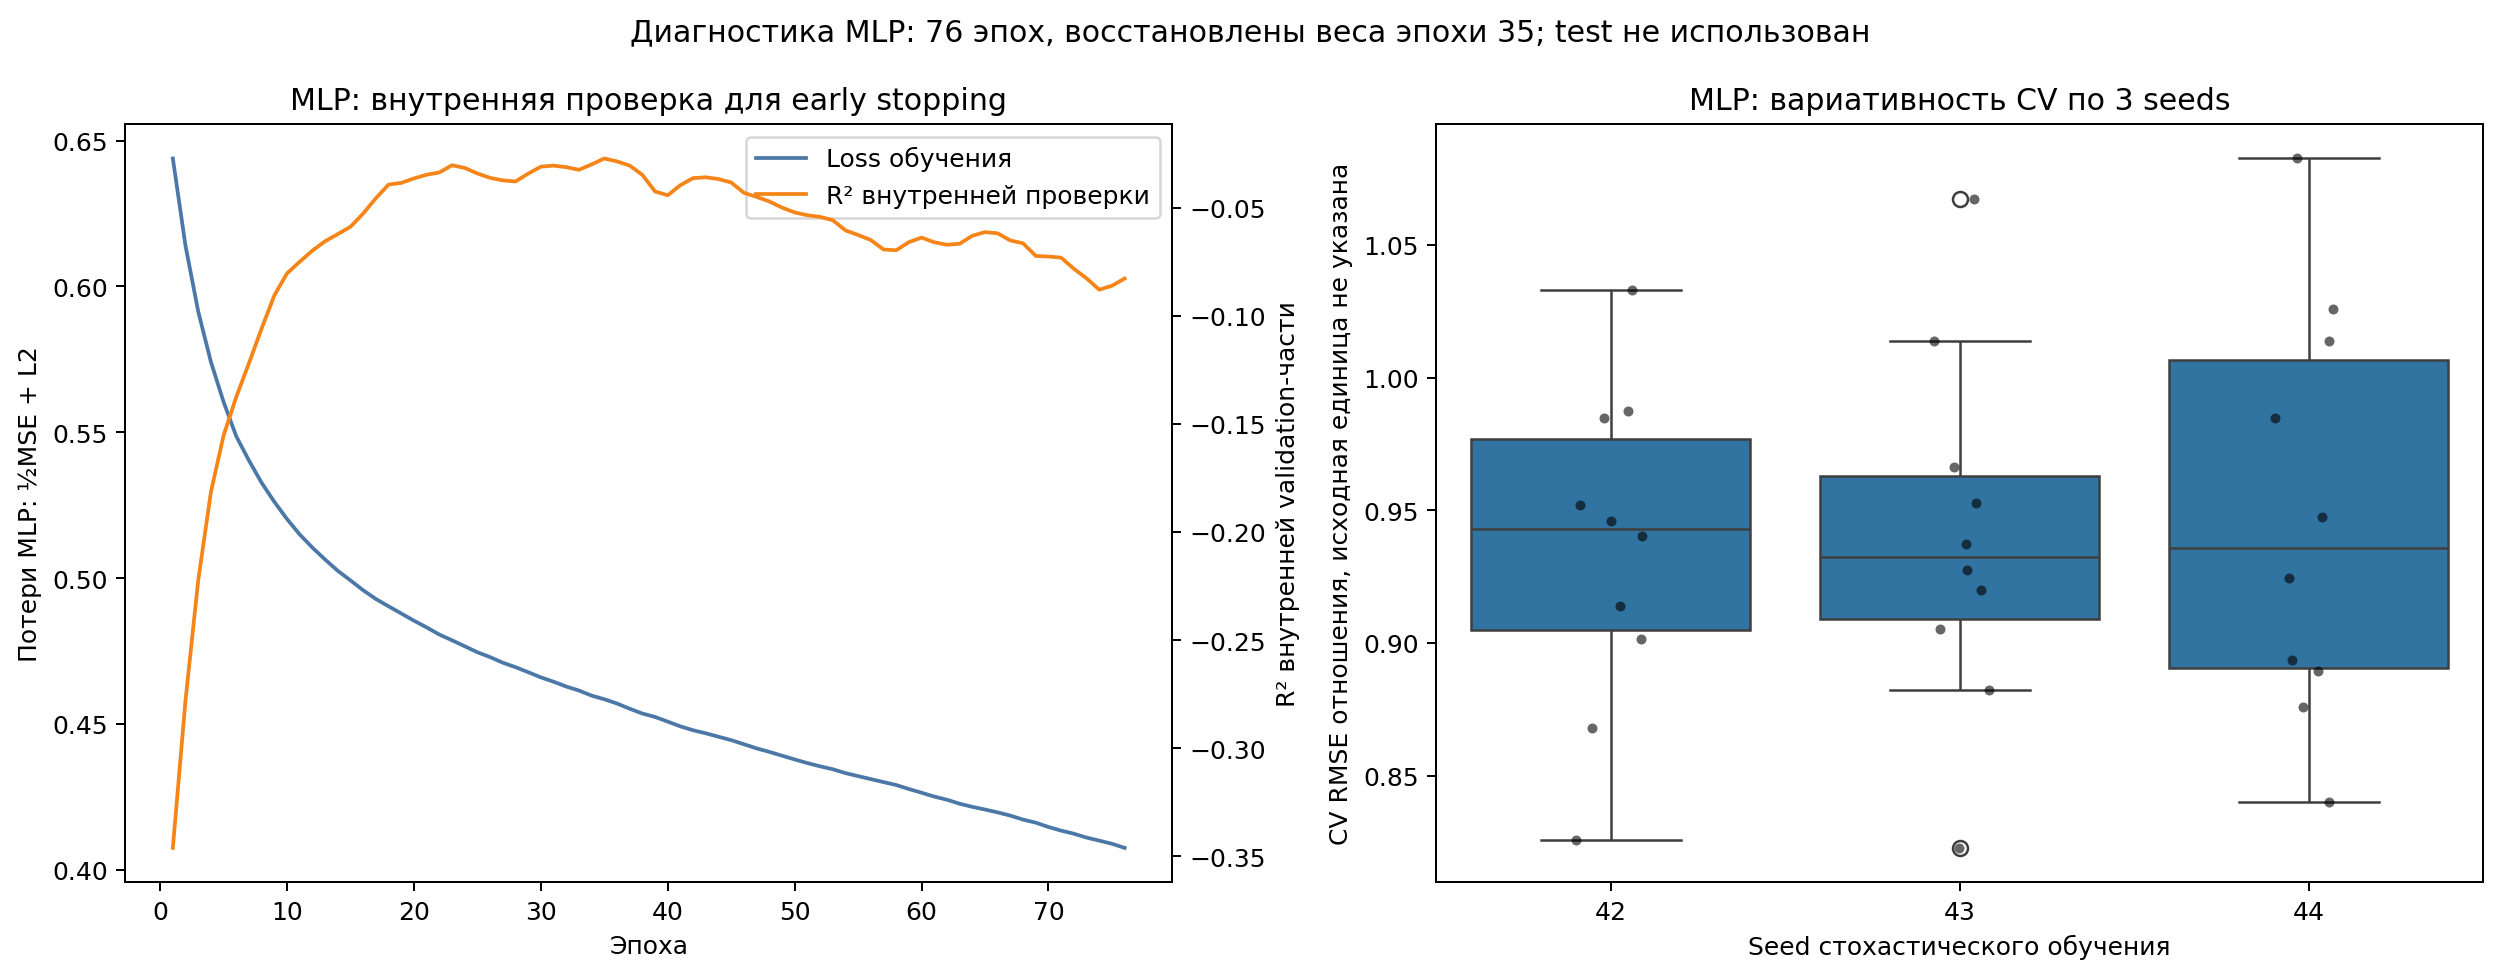

permutation_importance.png


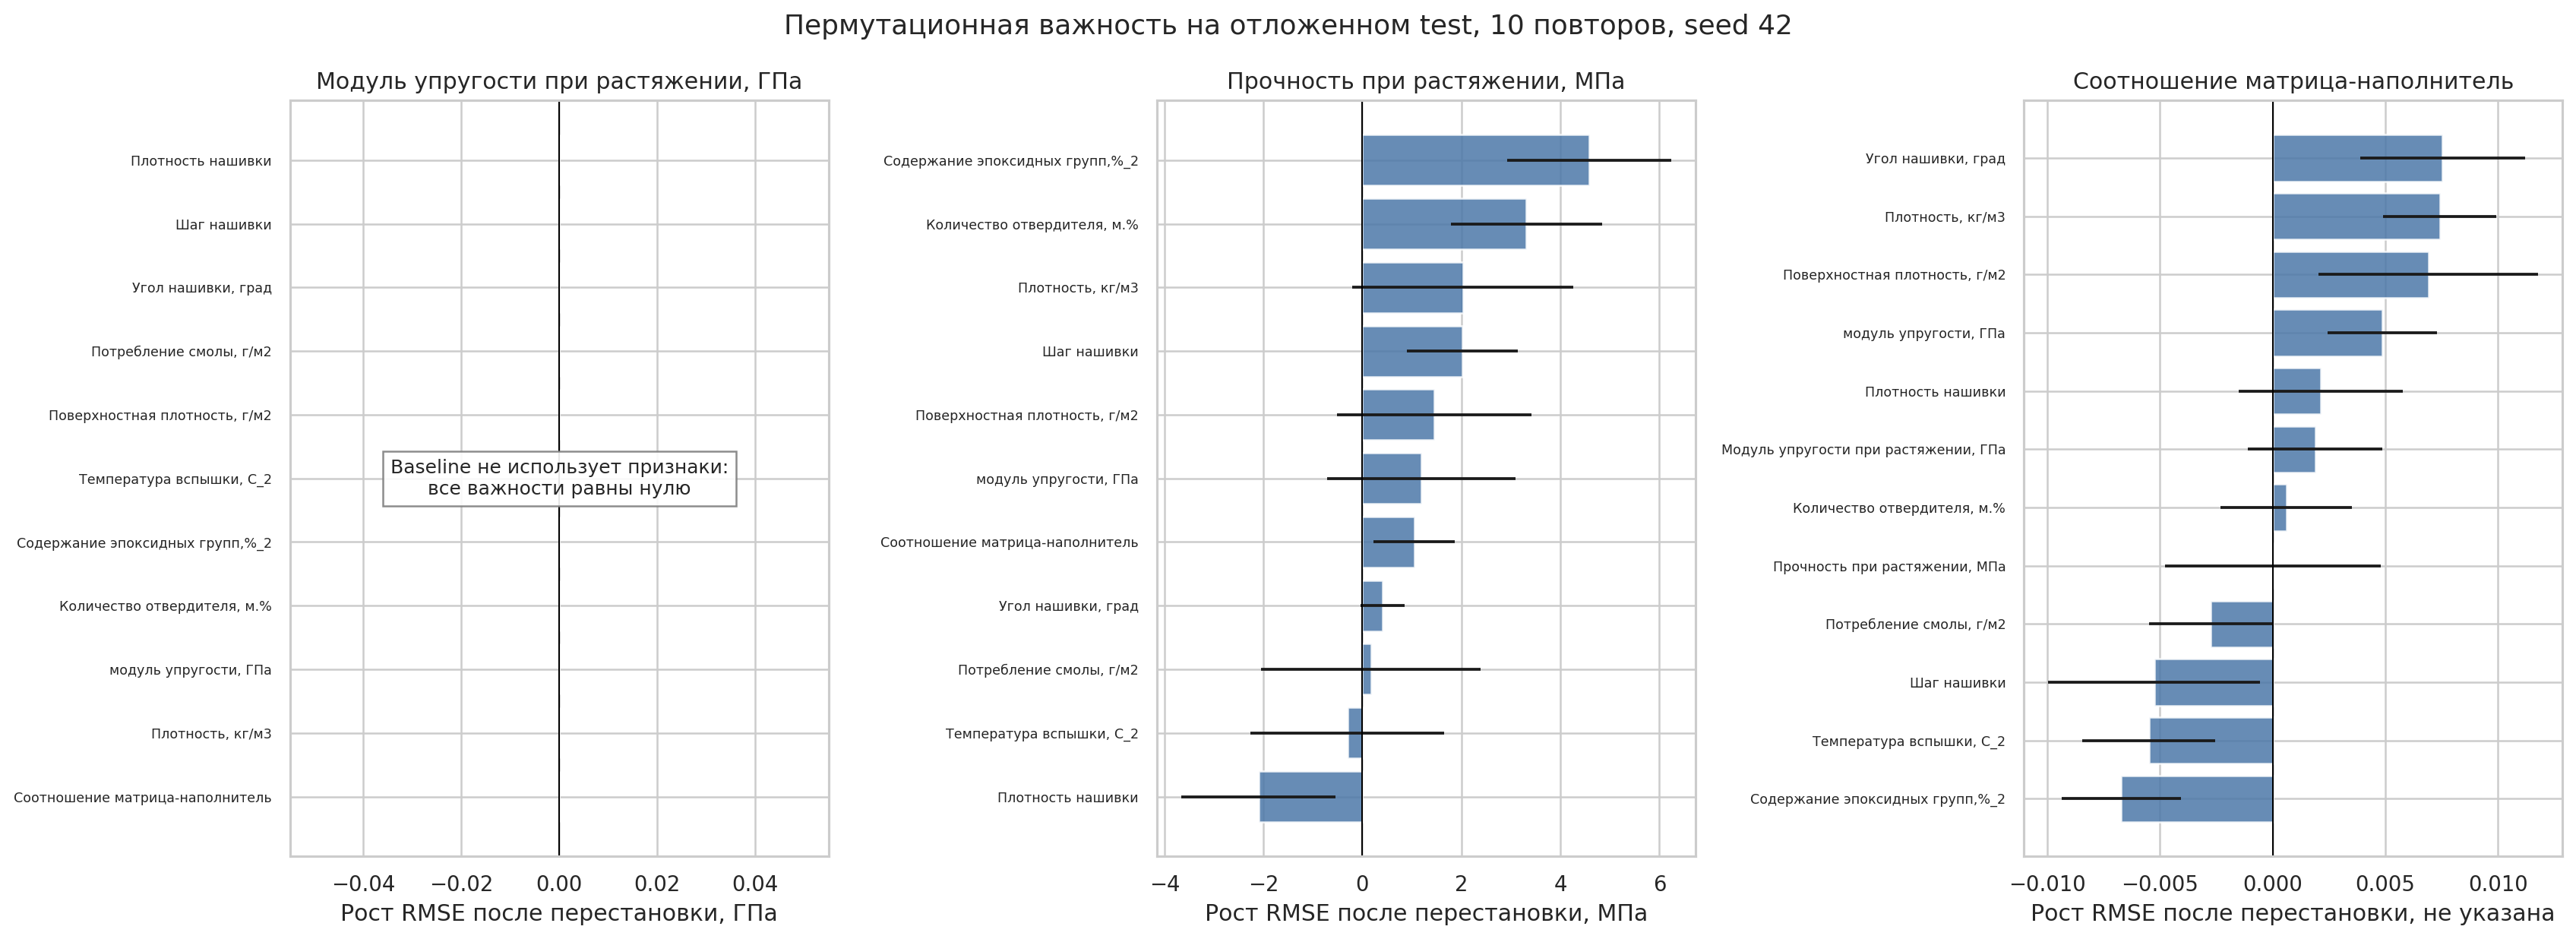

predicted_vs_actual.png


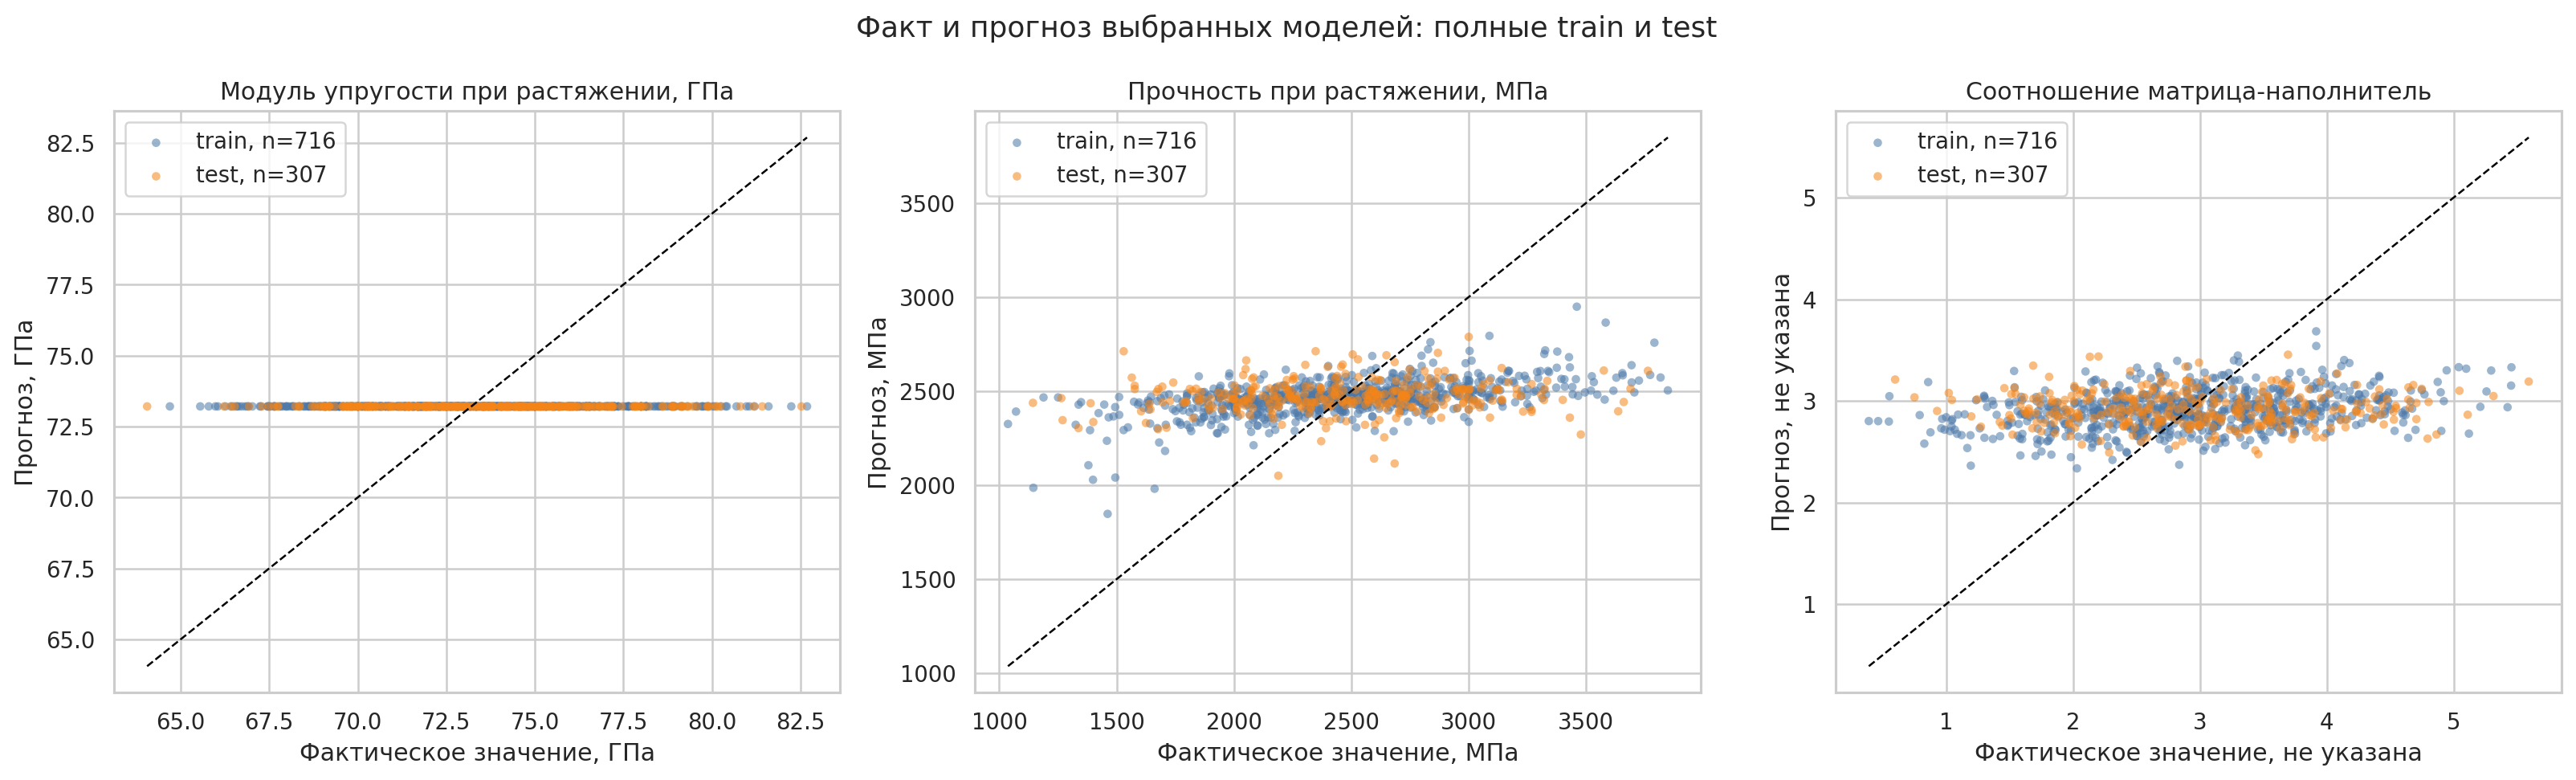

residuals.png


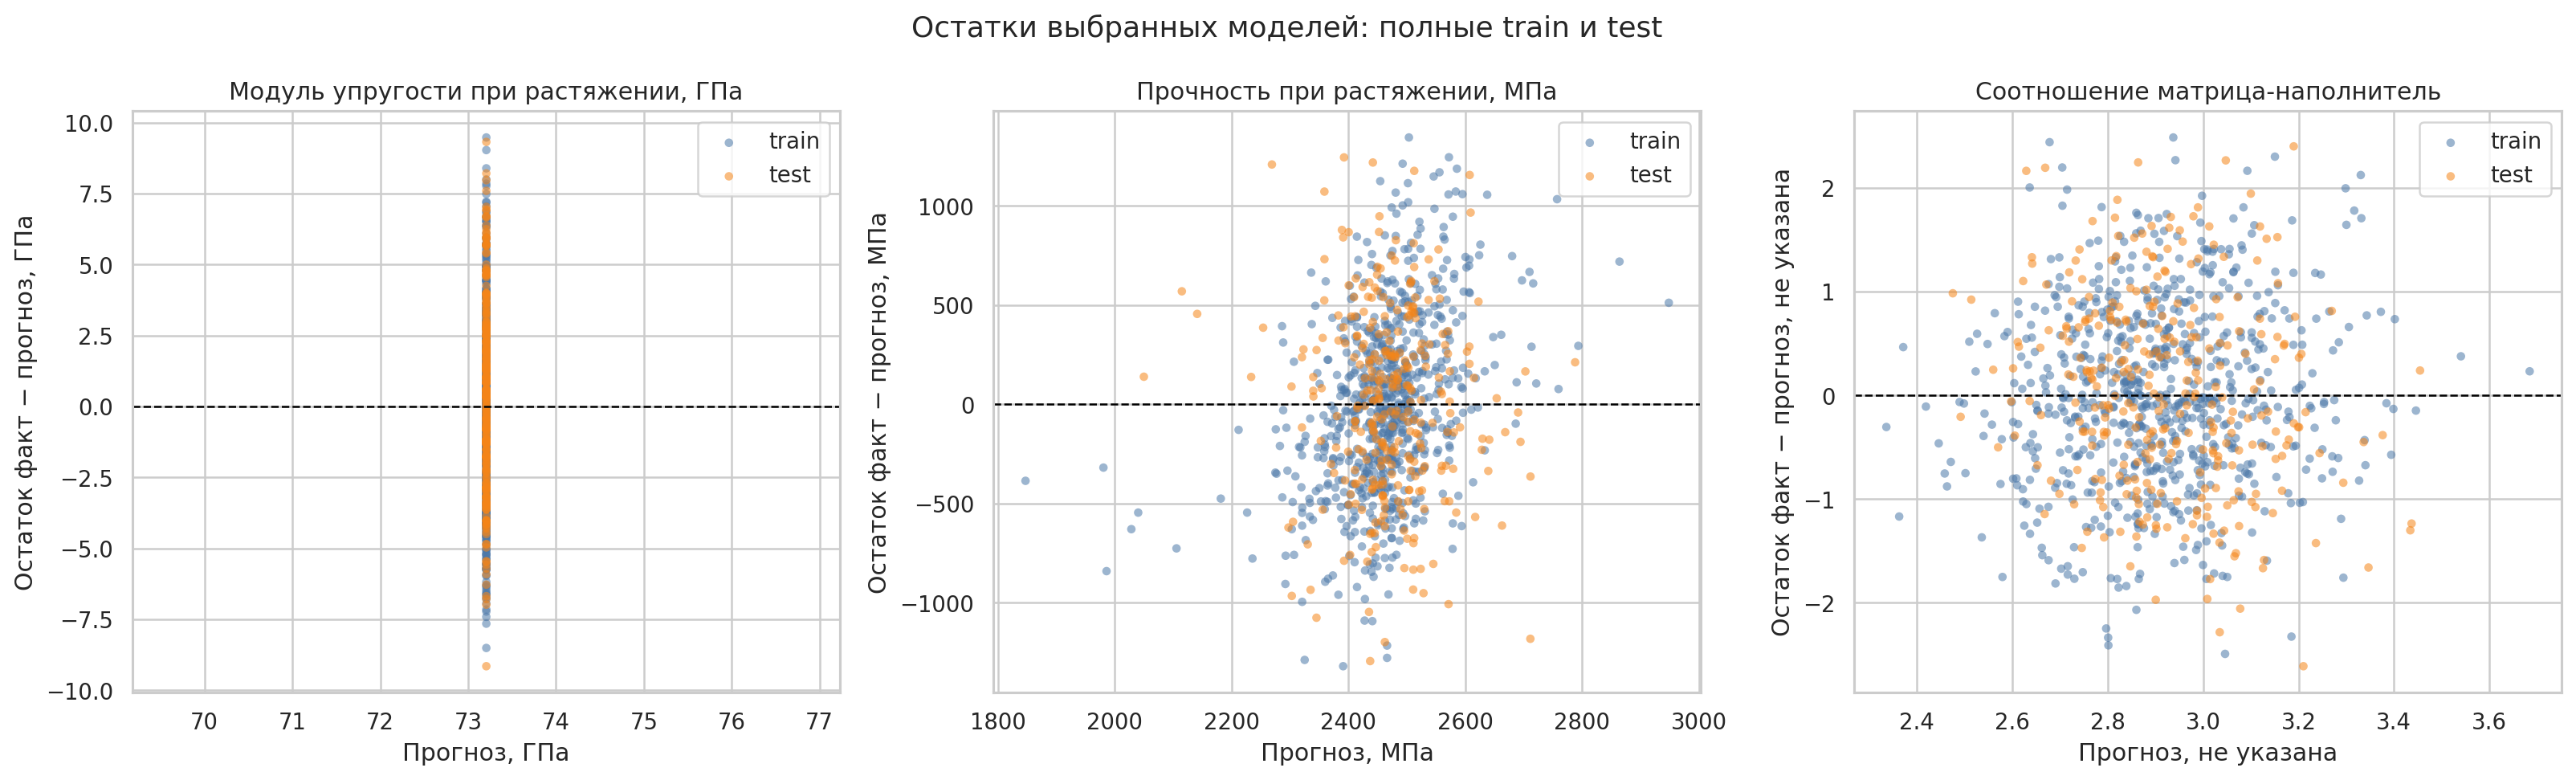

,all_evaluation_figures
0,figures/evaluation/nn_diagnostics.png
1,figures/evaluation/permutation_importance.png
2,figures/evaluation/permutation_importance_dire...
3,figures/evaluation/permutation_importance_dire...
4,figures/evaluation/permutation_importance_matr...
5,figures/evaluation/predicted_vs_actual.png
6,figures/evaluation/residuals.png


In [16]:
representative_names = {
    "predicted_vs_actual.png",
    "residuals.png",
    "nn_diagnostics.png",
    "permutation_importance.png",
}
for figure in [path for path in evaluation_figures if path.name in representative_names]:
    print(figure.name)
    display(Image(filename=str(figure)))
display(
    pd.DataFrame(
        {"all_evaluation_figures": [str(path.relative_to(PROJECT_ROOT)) for path in evaluation_figures]}
    )
)

### Permutation importance

Уменьшение качества при перестановке признака описывает зависимость данной
модели в наблюдавшейся выборке. Оно не доказывает причинность и может
распределяться между коррелирующими признаками.

In [17]:
display(
    importance.sort_values(["task", "importance_mean_rmse"], ascending=[True, False])
)

,task,family,feature,importance_mean_rmse,importance_std_rmse
0,direct_tensile_modulus,baseline,Соотношение матрица-наполнитель,0.000000,0.000000
1,direct_tensile_modulus,baseline,"Плотность, кг/м3",0.000000,0.000000
2,direct_tensile_modulus,baseline,"модуль упругости, ГПа",0.000000,0.000000
3,direct_tensile_modulus,baseline,"Количество отвердителя, м.%",0.000000,0.000000
4,direct_tensile_modulus,baseline,"Содержание эпоксидных групп,%_2",0.000000,0.000000
5,direct_tensile_modulus,baseline,"Температура вспышки, С_2",0.000000,0.000000
6,direct_tensile_modulus,baseline,"Поверхностная плотность, г/м2",0.000000,0.000000
7,direct_tensile_modulus,baseline,"Потребление смолы, г/м2",0.000000,0.000000
8,direct_tensile_modulus,baseline,"Угол нашивки, град",0.000000,0.000000
9,direct_tensile_modulus,baseline,Шаг нашивки,0.000000,0.000000


## Инференс двух прямых свойств

Демонстрационный ввод ниже состоит из медиан train, сохранённых в manifest.
Это не измеренный новый образец. Для содержательного прогноза словарь нужно
заменить фактическими характеристиками материала; выход за train-диапазон
означает экстраполяцию.

In [18]:
predictor = load_direct_predictor(MODELS_DIR)
demonstration_input = predictor.defaults()
display(pd.Series(demonstration_input, name="train median demonstration"))
display(predictor.predict(demonstration_input))

Соотношение матрица-наполнитель       2.900123
Плотность, кг/м3                   1973.063180
модуль упругости, ГПа               738.736842
Количество отвердителя, м.%         110.282718
Содержание эпоксидных групп,%_2      22.200872
Температура вспышки, С_2            284.615385
Поверхностная плотность, г/м2       449.051543
Потребление смолы, г/м2             219.478456
Угол нашивки, град                   90.000000
Шаг нашивки                           6.862404
Плотность нашивки                    57.231437
Name: train median demonstration, dtype: float64

,"Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
0,73.207346,2502.064032


## Ограничения выводов

Случайное разбиение оценивает качество на отложенных строках имеющейся таблицы.
Паспорт не сообщает партии, серии, типы матрицы и наполнителя, а часть единиц
неизвестна. Поэтому метрики не подтверждают перенос на новые классы материалов,
а приложение демонстрирует ограниченные модели и не заменяет испытания.